In [1]:
cd ..

/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN


/Users/hjp/anaconda3/envs/GarmentCode/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!pwd

/Users/hjp/HJP/KUAICV/VTO/CLO_AUTO_GEN


In [3]:
import os 
import sys

sys.path.append(os.path.dirname(os.getcwd()))

from env_constants import PYGARMENT_ROOT

sys.path.append(PYGARMENT_ROOT)
import pygarment as pyg

from sewing_pattern import (
    Stitch, StitchDict, SVGPanel, SewingPattern,
    # ParameterizedSeamLine, ParameterizedEdgeLine,
    # UnconstrainedFewViewLabel
)

In [4]:
import os
from glob import glob
import pickle

garment_path_list = sorted(glob(os.path.join("SAMPLE_DATA", "0814", "*")))

sample_ann_path = glob(os.path.join(garment_path_list[0], "*.pkl"))[0]

sample_ann = pickle.load(open(sample_ann_path, "rb"))

In [26]:
from glob import glob
from tqdm import tqdm
from copy import deepcopy
import os
from pathlib import Path

import random
import matplotlib.pyplot as plt
import numpy as np
import cv2
import pickle
from PIL import Image

from typing import List, Dict
from dataclasses import dataclass

import svgpathtools as svgpath

@dataclass
class SeamLine :
    segment_idx_arr_list : List[np.ndarray]
    segment_pos_arr_list : List[np.ndarray]
    segment_edge_len_arr_list : List[np.ndarray]
    segment_t_arr_list : List[np.ndarray]
    segment_u_arr_list : List[np.ndarray]
    segment_v_arr_list : List[np.ndarray]
    
    def translate(self, dx : float, dy : float) :
        for segment_pos_arr in self.segment_pos_arr_list :
            segment_pos_arr[:, 0] += dx
            segment_pos_arr[:, 1] += dy


class SingleViewLabel :
    """
    class for single view image plus seam line annotation
    """
    def __init__(self,
        img : np.ndarray,
        seam_annotation : Dict[str, Dict[int, SeamLine]],
    ) :
        self.img = img
        self.seam_annotation = seam_annotation
        
    @staticmethod
    def from_file_path(
        img_path : str,
        seam_annotation_path : str,
    ) :
        img = cv2.imread(
            img_path,
            cv2.IMREAD_UNCHANGED
        )
        seam_annotation_raw = pickle.load(open(seam_annotation_path, "rb"))
        
        seam_annotation = {}
        for garment_id, seam_line_dict in seam_annotation_raw.items() :
            seam_annotation[garment_id] = {}
            for stch_idx, seam_line in seam_line_dict.items() :
                seam_annotation[garment_id][stch_idx] = SeamLine(
                    segment_idx_arr_list = seam_line["segment_idx_arr_list"],
                    segment_pos_arr_list = seam_line["segment_pos_arr_list"],
                    segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                    segment_t_arr_list = seam_line["segment_t_arr_list"],
                    segment_u_arr_list = seam_line["segment_u_arr_list"],
                    segment_v_arr_list = seam_line["segment_v_arr_list"],
                )
        return SingleViewLabel(img, seam_annotation)
        
    def crop(self, crop_l : int, crop_t : int, crop_r : int, crop_b : int) :
        """
        crop_l, crop_t, crop_r, crop_b : int
        """
        # self.img = self.img.crop((crop_l, crop_t, crop_r, crop_b))
        self.img = self.img[crop_t:crop_b, crop_l:crop_r].copy()
        
        self.translate_seam_line(-crop_l, -crop_t)
        
        
    def pad(
        self, pad_l : int, pad_t : int, pad_r : int, pad_b : int) :
        """
        pad the image and the foreground mask
        """
        self.img = np.pad(
            self.img,
            pad_width=((pad_t, pad_b), (pad_l, pad_r), (0, 0)),
            mode="constant",
            constant_values=255
        )
        self.translate_seam_line(pad_l, pad_t)
        
    def translate_seam_line(self, dx : float, dy : float) :
        for garment_name, seam_line_dict in self.seam_annotation.items() :
            for seam_line_idx, seam_line_info in seam_line_dict.items() :
                seam_line_info.translate(dx, dy)
    
    def draw(self) :
        vis_seam_seg_pos_list = []
        for garment_id, seam_line_dict in self.seam_annotation.items() :
            for stch_idx, seam_line in seam_line_dict.items() :
                for segment_pos_arr in seam_line.segment_pos_arr_list :
                    vis_seam_seg_pos_list.append(segment_pos_arr)
        
        color_list = plt.cm.rainbow(np.linspace(0, 1, len(vis_seam_seg_pos_list)))
        
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(self.img, cv2.COLOR_BGRA2RGBA))
        
        plt.subplot(1, 2, 2)
        plt.imshow(cv2.cvtColor(self.img, cv2.COLOR_BGRA2RGBA))
        
        for pos_arr, color in zip(vis_seam_seg_pos_list, color_list) :
            plt.plot(pos_arr[:, 0], pos_arr[:, 1], color=color)

class FewViewLabel :
    def __init__(
        self,
        sewing_pattern_dict : Dict[str, SewingPattern],
        img_list : List[np.ndarray],
        seam_annotation_list : List[Dict[str, Dict[int, SeamLine]]],
        garment_dir : str = None,
    ) :
        self.img_list = img_list
        self.orig_annotation_list = seam_annotation_list
        self.seam_annotation_list = deepcopy(seam_annotation_list)
        self.combined_img = None
        self.sewing_pattern_dict = sewing_pattern_dict
        self.garment_dir = garment_dir
        
        self.seam_color_list_dict = {}
        for garment_id, sewing_pattern in sewing_pattern_dict.items() :
            self.seam_color_list_dict[garment_id] = plt.cm.rainbow(np.linspace(0, 1, len(sewing_pattern.stitch_dict)))

    @staticmethod
    def from_file_path(
        sewing_pattern_path_dict : Dict[str, str],
        img_path_list : List[str],
        seam_annotation_path_list : List[str],
        garment_dir : str = None,
    ) :
        img_list = [cv2.imread(img_path, cv2.IMREAD_UNCHANGED) for img_path in img_path_list]
        seam_annotation_list_raw = [pickle.load(open(seam_annotation_path, "rb")) for seam_annotation_path in seam_annotation_path_list]

        seam_annotation_list = []
        for seam_annotation_raw in seam_annotation_list_raw :
            seam_annotation = {}
            for garment_id, seam_line_dict in seam_annotation_raw.items() :
                seam_annotation[garment_id] = {}
                for stch_idx, seam_line in seam_line_dict.items() :
                    seam_annotation[garment_id][stch_idx] = SeamLine(
                        segment_idx_arr_list = seam_line["segment_idx_arr_list"],
                        segment_pos_arr_list = seam_line["segment_pos_arr_list"],
                        segment_edge_len_arr_list = seam_line["segment_edge_len_arr_list"],
                        segment_t_arr_list = seam_line["segment_t_arr_list"],
                        segment_u_arr_list = seam_line["segment_u_arr_list"],
                        segment_v_arr_list = seam_line["segment_v_arr_list"],
                    )
            seam_annotation_list.append(seam_annotation)

        sewing_pattern_dict = {}
        for garment_id, spec_path in sewing_pattern_path_dict.items() :
            pattern = pyg.pattern.wrappers.VisPattern(spec_path)
            panel_svg_path_dict = {
                panel_name : pattern._draw_a_panel(
                    panel_name, apply_transform=False, fill=True
                )
                for panel_name in pattern.panel_order()
            }
            stitch_dict = {
                i : v for i, v in enumerate(pattern.pattern['stitches'])
            }
            sewing_pattern = SewingPattern(panel_svg_path_dict, stitch_dict)
            sewing_pattern_dict[garment_id] = sewing_pattern

        return FewViewLabel(
            sewing_pattern_dict,
            img_list,
            seam_annotation_list,
            garment_dir,
        )

    @staticmethod
    def from_dir(
        scene_dir : str,
        garment_version : str = "01",
        selected_idx_list : List[int] = None,
    ) :
        garment_id_list = str(Path(scene_dir).name).split("__")[::2]
        
        spec_path_dict = {}
        for garment_id in garment_id_list :
            spec_path = str(Path(scene_dir) / f"{garment_id}__{garment_version}__specification.json")
            if os.path.exists(spec_path) :
                spec_path_dict[garment_id] = spec_path
            else :
                spec_path = str(Path(scene_dir) / f"{garment_id}_specification.json")
                spec_path_dict[garment_id] = spec_path
        
        annotation_path_list = sorted(
            glob(os.path.join(scene_dir, "*.pkl")),
            key = lambda x : int(Path(x).stem.split("_")[2])
        )
        
        img_path_list = list(map(
            lambda x : x.replace(".pkl", ".png"),
            annotation_path_list
        ))
        
        if selected_idx_list is not None :
            img_path_list = [img_path_list[i] for i in selected_idx_list]
            annotation_path_list = [annotation_path_list[i] for i in selected_idx_list]
        
        return FewViewLabel.from_file_path(
            spec_path_dict,
            img_path_list,
            annotation_path_list,
            garment_dir = scene_dir,
        )
        

    def get_fg_bbox(self, img : np.ndarray) :
        """
        image must be png.
        """
        img_mask = img[:, :, 3]
        fg_ycoord, fg_xcoord = np.where(img_mask > 0)
        fg_ycoord_min = np.min(fg_ycoord)
        fg_ycoord_max = np.max(fg_ycoord)
        fg_xcoord_min = np.min(fg_xcoord)
        fg_xcoord_max = np.max(fg_xcoord)
        return (fg_xcoord_min, fg_ycoord_min, fg_xcoord_max, fg_ycoord_max)

    def combine_views(self) :
        if len(self.img_list) == 1 :
            IMG_H, IMG_W = self.img_list[0].shape[:2]
            img_bbox_x1, img_bbox_y1, img_bbox_x2, img_bbox_y2 = self.get_fg_bbox(self.img_list[0])
            crop_t = random.randint(0, img_bbox_y1)
            crop_b = random.randint(img_bbox_y2, IMG_H - 1)
            crop_l = random.randint(0, img_bbox_x1)
            crop_r = random.randint(img_bbox_x2, IMG_W - 1)
            self.combined_img = self.crop_img(self.img_list[0], crop_l, crop_t, crop_r, crop_b)
            self.translate_seam_line(self.seam_annotation_list[0], -crop_l, -crop_t)
            return
            
        bb_w_list = []
        bb_h_list = []
        for img in self.img_list :
            x1, y1, x2, y2 = self.get_fg_bbox(img)
            bb_w_list.append(x2 - x1)
            bb_h_list.append(y2 - y1)
        if len(self.img_list) in [2, 3] :
            h = np.max(bb_h_list)
            x_pos = 0
            img_list = []
            for (img, bb_w, ann_dict) in zip(
                self.img_list,
                bb_w_list,
                self.seam_annotation_list
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                
                img = self.pad_img(img, x1=0, x2=0, y1=0, y2=h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_pos - x1, -
                                         y1)
                img_list.append(img)
                x_pos += bb_w
            self.combined_img = np.hstack(img_list)
            
        elif len(self.img_list) == 4 :
            row1_h = max(bb_h_list[0], bb_h_list[1])
            row1_w = bb_w_list[0] + bb_w_list[1]
            row2_h = max(bb_h_list[2], bb_h_list[3])
            row2_w = bb_w_list[2] + bb_w_list[3]
            w = max(row1_w, row2_w)
            
            x_offset = 0
            img_list_upper = []
            for (img, bb_w, x2_margin, ann_dict) in zip(
                self.img_list[:2],
                bb_w_list[:2],
                [0, w - row1_w],
                self.seam_annotation_list[:2],
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                img = self.pad_img(
                    img, x1=0, x2=x2_margin, y1=0, y2=row1_h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_offset - x1, -y1)
                img_list_upper.append(img)
                x_offset += bb_w
            
            x_offset = 0
            img_list_lower = []
            for (img, bb_w, x2_margin, ann_dict) in zip(
                self.img_list[2:],
                bb_w_list[2:],
                [0, w - row2_w],
                self.seam_annotation_list[2:],
            ) :
                x1, y1, x2, y2 = self.get_fg_bbox(img)
                img = self.crop_img(img, x1, y1, x2, y2)
                img = self.pad_img(
                    img, x1=0, x2=x2_margin, y1=0, y2=row2_h - (y2 - y1))
                self.translate_seam_line(ann_dict, x_offset - x1, row1_h - y1)
                img_list_lower.append(img)
                x_offset += bb_w
                
            self.combined_img = np.vstack([
                np.hstack(img_list_upper),
                np.hstack(img_list_lower),
            ])
    
    def translate_seam_line(self, seam_ann_dict, dx : float, dy : float) :
        for garment_id, seam_line_dict in seam_ann_dict.items() :
            for stch_idx, seam_line in seam_line_dict.items() :
                seam_line.translate(dx, dy)

    def crop_img(self, img, x1, y1, x2, y2) :
        img = img[y1:y2, x1:x2].copy()
        return img
    
    def pad_img(self, img, x1, y1, x2, y2) :
        img = np.pad(
            img,
            pad_width=(
                (y1, y2), (x1, x2), (0, 0)
            ),
            mode="constant", constant_values=255
        )
        return img
    
    def make_residual(
        self,
        perterb_ratio : float = 0.1,
    ) :
        self.residual_sewing_pattern_dict = deepcopy(self.sewing_pattern_dict)
        
        for garment_id, sewing_pattern in self.residual_sewing_pattern_dict.items() :
            for panel_name, panel in sewing_pattern.panel_dict.items() :
                panel_no_arc = deepcopy(panel)
                panel_no_arc.approximate_arc_with_cubic_bezier()
                
                stt_pos = panel_no_arc.svg_path[0].start
                prev_end_pos = panel_no_arc.svg_path[0].start
                
                new_svg_path = []
                for edge in panel_no_arc.svg_path :
                    scale = edge.length() * perterb_ratio
                    
                    if edge.end == stt_pos :
                        end_pos = edge.end
                    else :
                        end_x_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        end_y_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        end_pos = edge.end + end_x_perterb + end_y_perterb * 1j
                    
                    if isinstance(edge, svgpath.Line) :
                        new_svg_path.append(svgpath.Line(start = prev_end_pos, end = end_pos))
                    elif isinstance(edge, svgpath.CubicBezier) :
                        control1_x_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        control1_y_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        control2_x_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        control2_y_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                    
                        control1_pos = edge.control1 + control1_x_perterb + control1_y_perterb * 1j
                        control2_pos = edge.control2 + control2_x_perterb + control2_y_perterb * 1j
                        
                        new_svg_path.append(svgpath.CubicBezier(start=prev_end_pos, end=end_pos, control1=control1_pos, control2=control2_pos))
                    elif isinstance(edge, svgpath.QuadraticBezier) :
                    
                        control_x_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        control_y_perterb = random.uniform(-perterb_ratio, perterb_ratio) * scale
                        
                        control_pos = edge.control + control_x_perterb + control_y_perterb * 1j
                        
                        new_svg_path.append(svgpath.QuadraticBezier(start=prev_end_pos, end=end_pos, control=control_pos))
                    else :
                        raise ValueError(f"Unknown edge type: {type(edge)}")
                    
                    prev_end_pos = deepcopy(end_pos)
                    
                    
                new_panel = SVGPanel(svgpath.Path(*new_svg_path))
                
                self.residual_sewing_pattern_dict[garment_id].panel_dict[panel_name] = new_panel
                
            # self.residual_sewing_pattern_dict[garment_id].apply_panel_name_refine_map(
            #     panel_name_refine_map = self.sewing_pattern_dict[garment_id].panel_name_refine_map
            # )
                
                
        
    
    def draw(
        self,
        line_width : float = 3.0,
    ) :
        plt.subplot(1, 2, 1)
        
        try :
            plt.imshow(cv2.cvtColor(self.combined_img, cv2.COLOR_BGRA2RGBA))
        except :
            plt.imshow(cv2.cvtColor(self.img_list[0], cv2.COLOR_BGR2RGB))
        
        plt.subplot(1, 2, 2)
        
        try :
            plt.imshow(cv2.cvtColor(self.combined_img, cv2.COLOR_BGRA2RGBA))
        except :
            plt.imshow(cv2.cvtColor(self.img_list[0], cv2.COLOR_BGR2RGB))
        
        for seam_annotation in self.seam_annotation_list :
            for garment_id, seam_line_dict in seam_annotation.items() :
                for stch_idx, seam_line in seam_line_dict.items() :
                    for segment_pos_arr in seam_line.segment_pos_arr_list :
                        plt.plot(
                            segment_pos_arr[:, 0],
                            segment_pos_arr[:, 1],
                            color=self.seam_color_list_dict[garment_id][stch_idx],
                            linewidth=line_width,
                        )



garment_path_list = sorted(glob(os.path.join("SAMPLE_DATA", "0814", "*")))

In [6]:
import os
from glob import glob
from pathlib import Path

sample_dir = garment_path_list[0]

annot_path_list = sorted(
    glob(os.path.join(sample_dir, "*.pkl")),
    key = lambda x : int(Path(x).stem.split("_")[2])
)
annot_path_list

view_label_list = list(map(
    lambda x1, x2 : SingleViewLabel.from_file_path(x1, x2),
    list(map(
        lambda annot_path : annot_path.replace(".pkl", ".png"),
        annot_path_list
    )),
    annot_path_list,
))

SAMPLE_DATA/0814/rand_HXHHZQKHZE__01__rand_TIF3F5RMV2__01


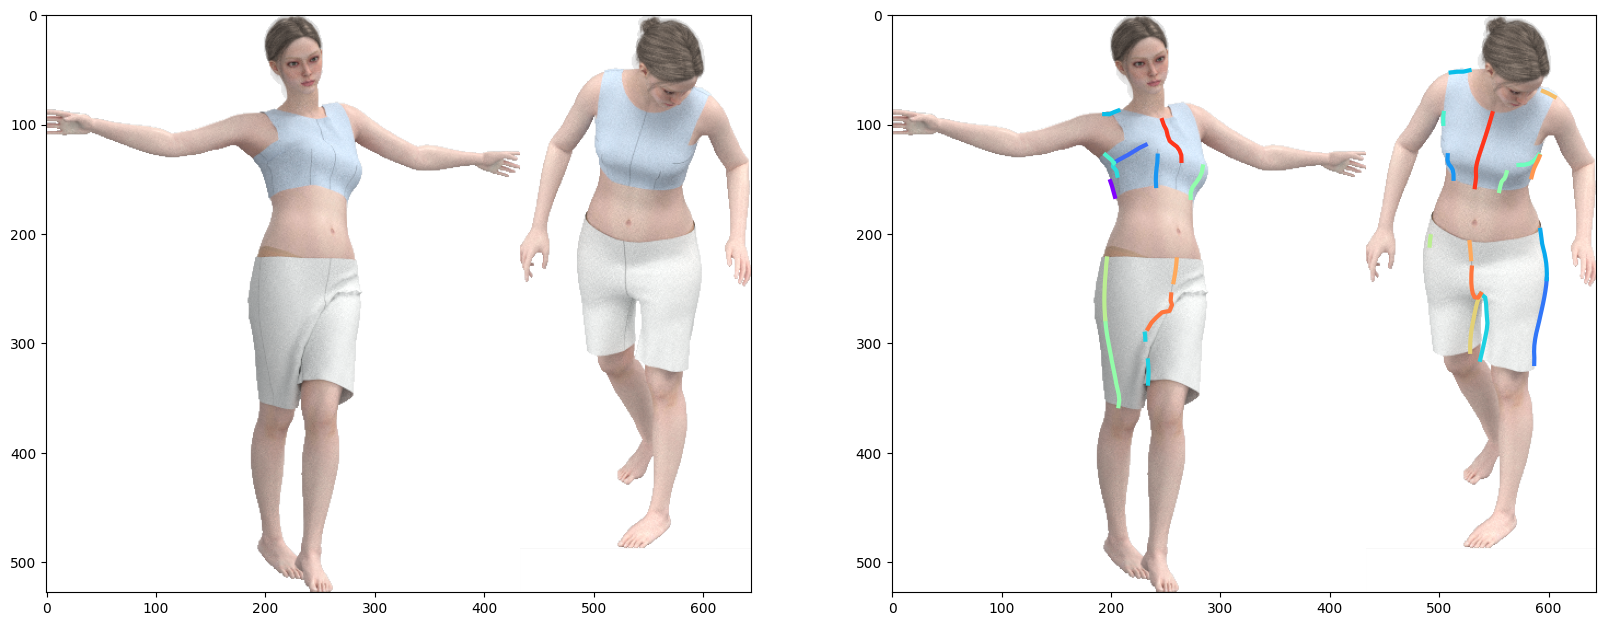

rand_HXHHZQKHZE


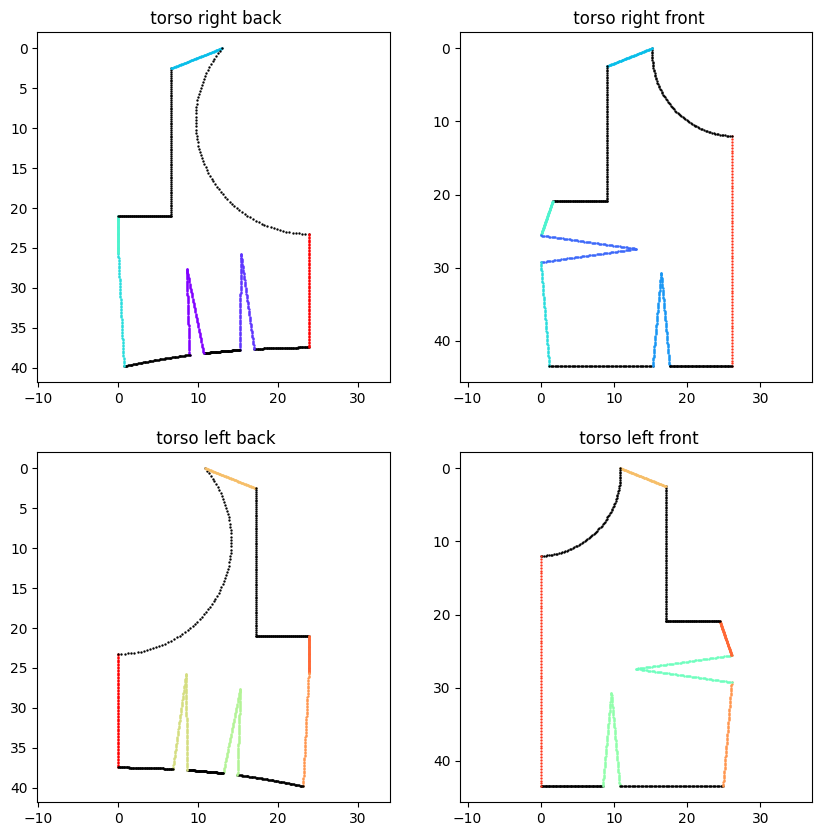

rand_TIF3F5RMV2


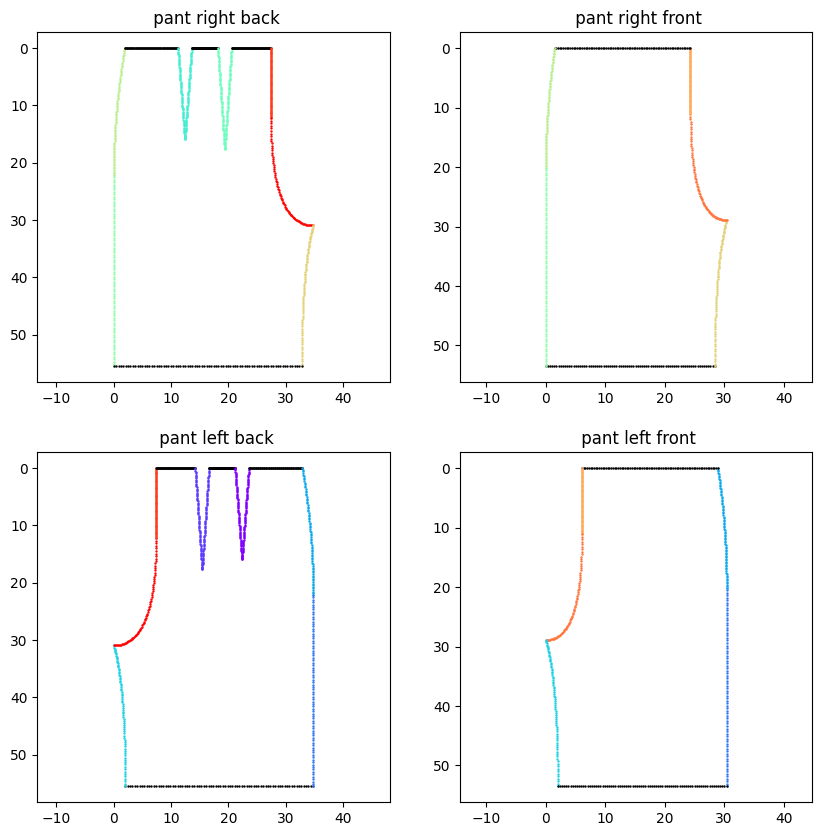

In [ ]:
import os
from glob import glob
from pathlib import Path
import random


panel_name_refine_map = {
    'left_collar_back'      : " collar left back",
    'left_collar_front'     : " collar left front",
    'right_collar_back'     : " collar right back",
    'right_collar_front'    : " collar right front",
    'left_hood'             : " hood left",
    'right_hood'            : " hood right",
    'pant_b_l'              : " pant left back",
    'pant_b_r'              : " pant right back",
    'pant_f_l'              : " pant left front",
    'pant_f_r'              : " pant right front",
    'pant_l_cuff_b'         : " pant cuff left back",
    'pant_l_cuff_f'         : " pant cuff left front",
    'pant_l_cuff_skirt_b'   : " pant cuff skirt left back",
    'pant_l_cuff_skirt_f'   : " pant cuff skirt left front",
    'pant_r_cuff_b'         : " pant cuff right back",
    'pant_r_cuff_f'         : " pant cuff right front",
    'pant_r_cuff_skirt_b'   : " pant cuff skirt right back",
    'pant_r_cuff_skirt_f'   : " pant cuff skirt right front",
    'left_btorso'           : " torso left back",
    'left_ftorso'           : " torso left front",
    'right_btorso'          : " torso right back",
    'right_ftorso'          : " torso right front",
    'left_sleeve_b'         : " sleeve left back",
    'left_sleeve_f'         : " sleeve left front",
    'skirt_back'            : " skirt back",
    'skirt_front'           : " skirt front",
    'right_sleeve_b'        : " sleeve right back",
    'right_sleeve_f'        : " sleeve right front",
    'sl_left_cuff_b'        : " sleeve cuff left back",
    'sl_left_cuff_f'        : " sleeve cuff left front",
    'sl_left_cuff_skirt_b'  : " sleeve cuff skirt left back",
    'sl_left_cuff_skirt_f'  : " sleeve cuff skirt left front",
    'sl_right_cuff_b'       : " sleeve cuff right back",
    'sl_right_cuff_f'       : " sleeve cuff right front",
    'sl_right_cuff_skirt_b' : " sleeve cuff skirt right back",
    'sl_right_cuff_skirt_f' : " sleeve cuff skirt right front",
    'wb_back'               : " waist band back",
    'wb_front'              : " waist band front",
}




good_garment_path_list = [
    "rand_52EP4QJLGQ__01__rand_S1RL0COYPS__01",
    "rand_53QD6WH0ST__01__rand_8G7N6W7FC4__01",
    "rand_53VIR9DPAS__01__rand_KIPTKV2CLQ__01",
    "rand_54KFRYT6NA__01__rand_M1T93KCG7E__01",
    "rand_58K9BF07ZA__01",
    "rand_5DY3AIHCOT__01__rand_CX5AXIQHNI__01",
    "rand_5POH1MHN4D__01__rand_LINCW20JZO__01",
    "rand_3WS8419T98__01",
    "rand_3YKPGXYGVG__01__rand_7SRESBECDF__01",
    "rand_40B81PVUQ2__01",
    "rand_479XSCBNPY__01",
    "rand_4YAT3UA7R8__01__rand_RAQBSB52SD__01",
    "rand_4YUSBEKIEW__01__rand_LW3935HGUA__01",
    "rand_6S2ZXXMSAN__01__rand_KVZGWRZW9V__01",
    "rand_6FCI14BH0F__01__rand_E2APO5A7R8__01",
    "rand_6TV00BGVH2__01",
    "rand_72PKKZ7KQO__01",
    "rand_7DVHZ4Z2QI__01",
    "rand_7JUXOOWT7M__01__rand_XTUV3QWJJK__01",
    "rand_7LIHWSA54O__01__rand_BGAZ1KPEMF__01",
    "rand_AKBI2OR18M__01__rand_RWZDY6BXLA__01",
    "rand_AKS7S180W3__01",
    "rand_ARLJF6F5A6__01__rand_DA6U9GKVUH__01",
    "rand_8BF1TGECH5__01",
    "rand_8C4GVKZS2H__01__rand_XKADFRB6OH__01",
    "rand_BP48IL1VCE__01__rand_WOQUDZY363__01",
    "rand_BW0C702IYP__01__rand_3AHQQK4O7N__01",
    "rand_9KD97VOWAM__01__rand_ZFWNJY73CK__01",
    "rand_CT9365544U__01__rand_RV8H2AT1JY__01",
    "rand_D5I1D9WP8U__01",
    "rand_DIVV7NZMOJ__01__rand_EUA743C247__01",
    "rand_DR8CO164JR__01__rand_8FV3A15E73__01",
    "rand_DWPSUB1O7Z__01__rand_OC13S0P8EP__01",
    "rand_E1JQFH83GO__01__rand_YJFTT698XZ__01",
    "rand_E72L588UKE__01",
    "rand_EJP0S4KWNM__01__rand_JS9K7VMXKE__01",
    "rand_F3OT73RNC7__01",
    "rand_GAXLYZ6NU6__01__rand_PTYS5OXS5H__01",
    "rand_G78KVPZB0W__01__rand_HF3TVP0M14__01",
    "rand_HTWC3YBD4Z__01__rand_JO6EUV7N2T__01",
    "rand_HXHHZQKHZE__01__rand_TIF3F5RMV2__01",
    "rand_I4QJZL1AX8__01__rand_RLY6VM2F0A__01",
    "rand_IITHMZRQFZ__01__rand_5T2Q7JA5DL__01",
    "rand_IQISL0OCXZ__01__rand_B5TCJ4TD31__01",
]

good_garment_path_list = list(map(
    lambda x : os.path.join("SAMPLE_DATA", "0814", x),
    good_garment_path_list
))
# sample_dir = random.choice(good_garment_path_list)

# COUNT = 4
# SELECTED_VIEW_IDX_LIST = random.sample(range(10), COUNT)

# 심라인 안보임
IDX = 23 # 비대칭 토르소, 
IDX = 12 # 비대칭 슬리브


IDX = 29
IDX = 8
IDX = 30
IDX = 31
IDX = 32
IDX = 33
IDX = 34
IDX = 39
IDX = 40



sample_dir = good_garment_path_list[IDX]

#scene_name = "rand_IQISL0OCXZ__01__rand_B5TCJ4TD31__01"
SELECTED_VIEW_IDX_LIST = [2, 10]

# sample_dir = os.path.join("SAMPLE_DATA", "0814", scene_name)

print(sample_dir)

few_view_label = FewViewLabel.from_dir(
    sample_dir,
    selected_idx_list = SELECTED_VIEW_IDX_LIST,
)
for garment_id, sewing_pattern in few_view_label.sewing_pattern_dict.items() :
    sewing_pattern.apply_panel_name_refine_map(
        panel_name_refine_map = panel_name_refine_map
    )

few_view_label.combine_views()


plt.figure(figsize=(20, 10))
few_view_label.draw()
plt.show()

# plt.figure(figsize=(30, 20))
# plt.imshow(plt.imread(os.path.join(few_view_label.garment_dir, "thumbnail.png")))
# plt.show()

for garment_id, sewing_pattern in few_view_label.sewing_pattern_dict.items() :
    print(garment_id)
    sewing_pattern.draw(
        color_list = few_view_label.seam_color_list_dict[garment_id],
        plot_stitch_name=False,
        unify_plot_scale=True,
    )

    plt.show()
    
    

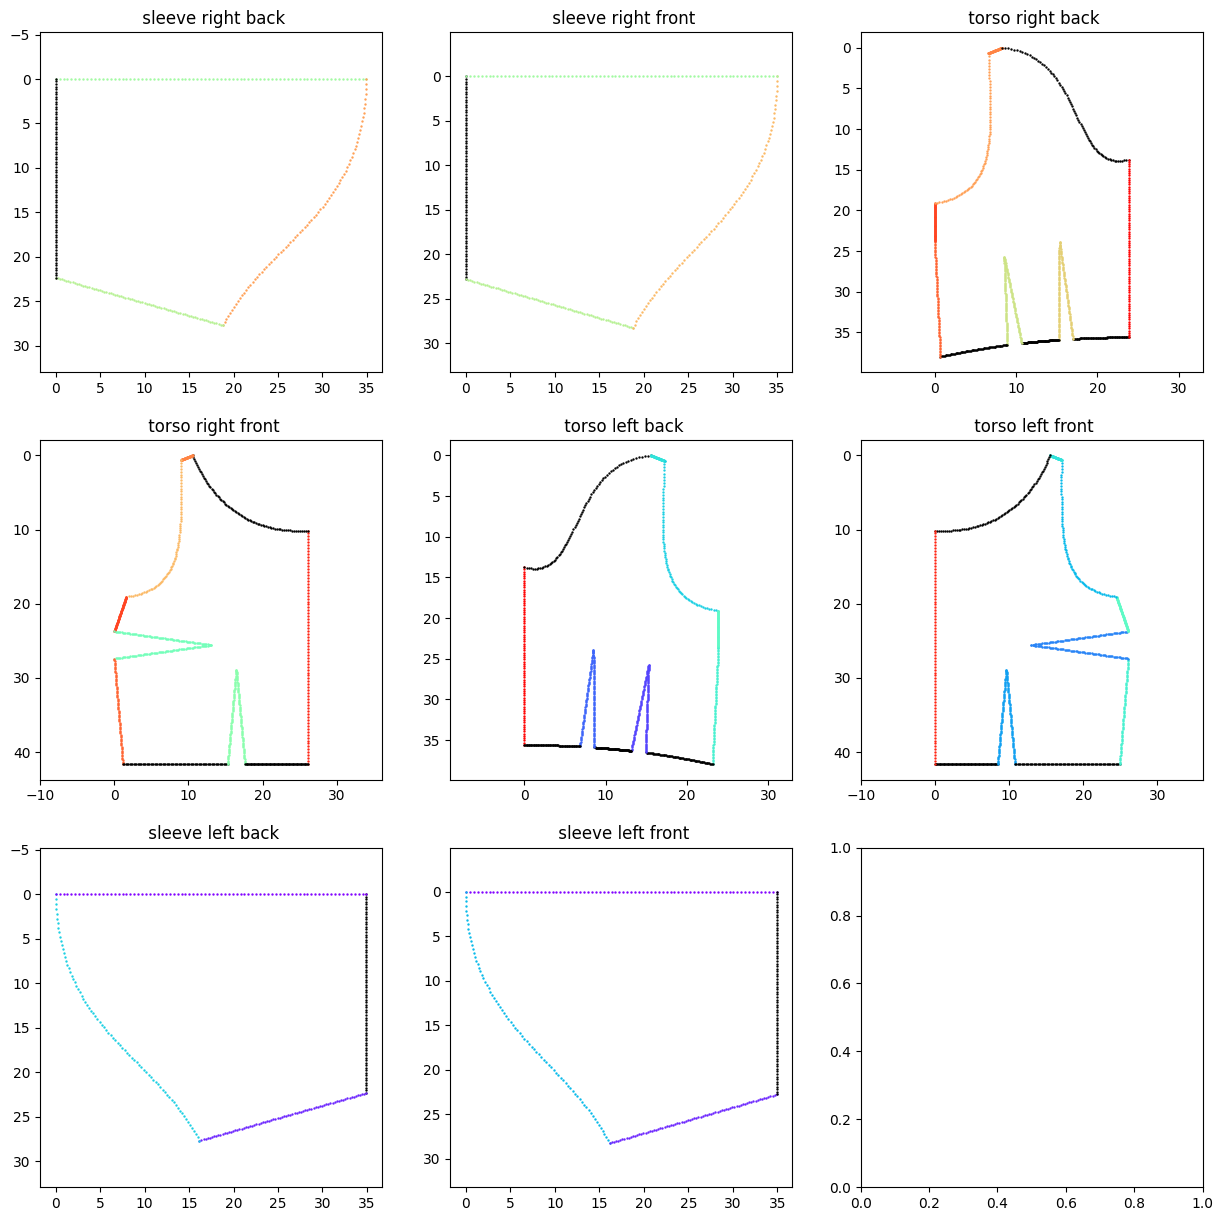

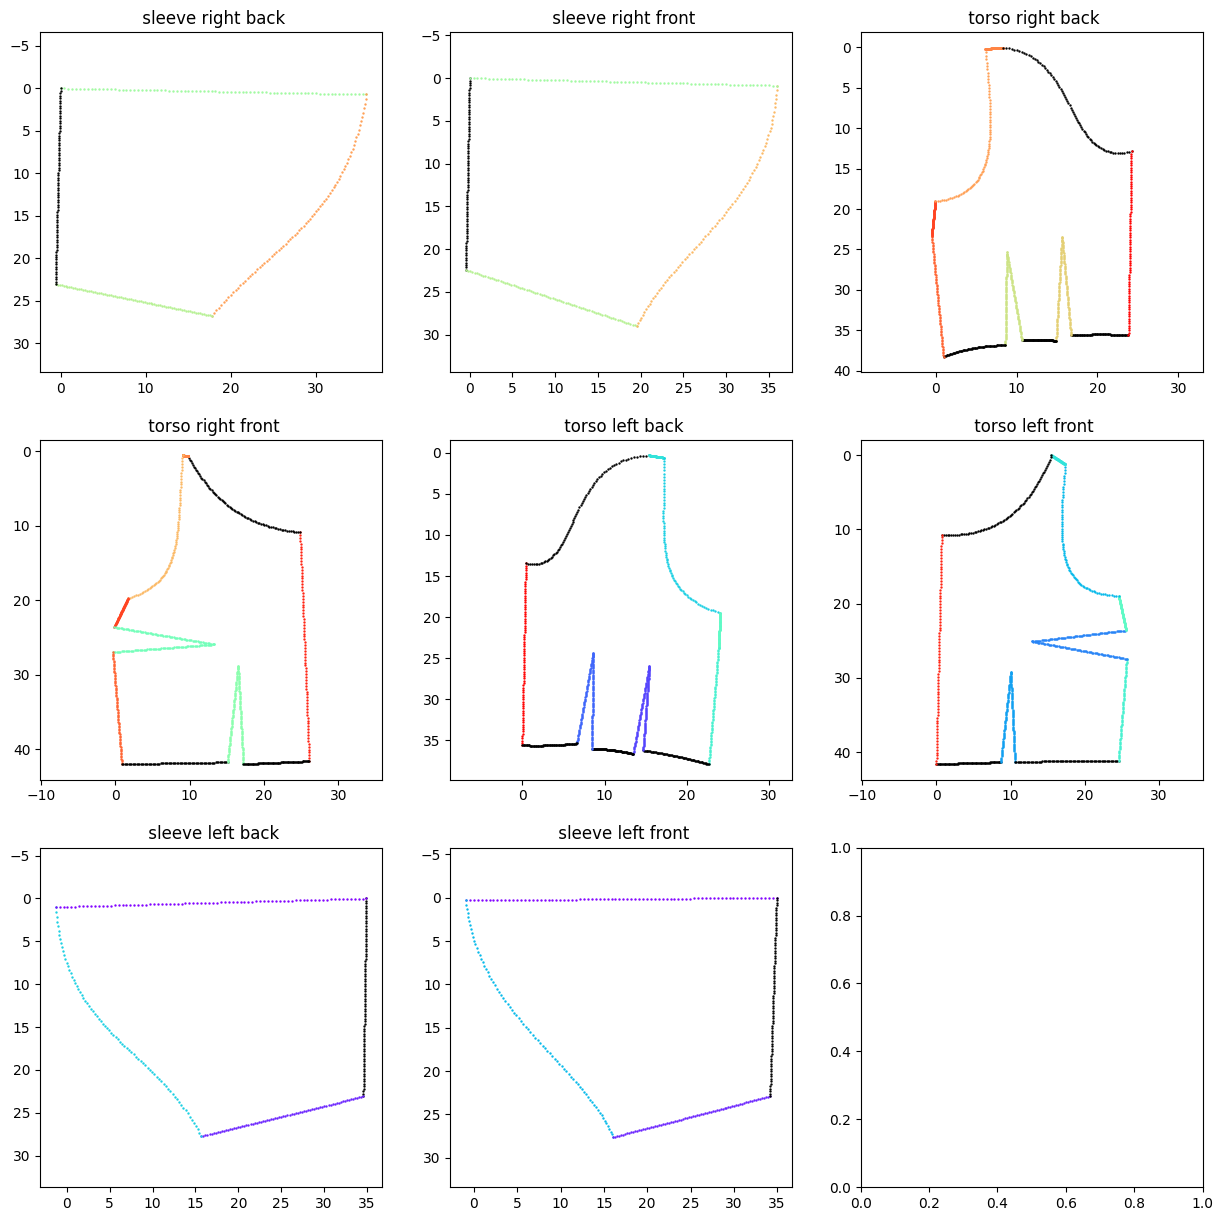

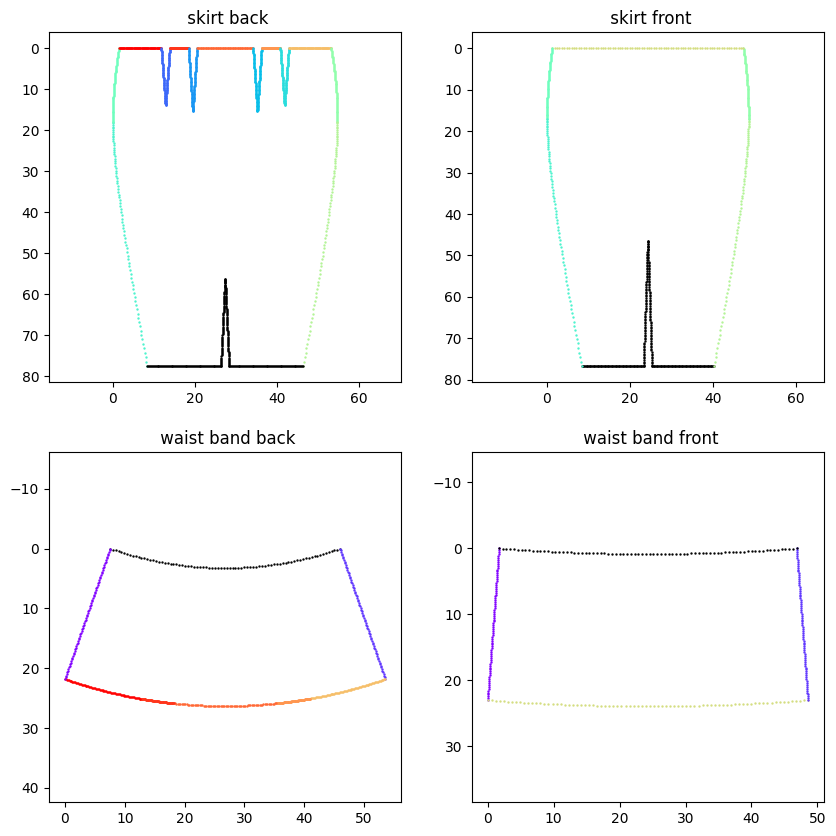

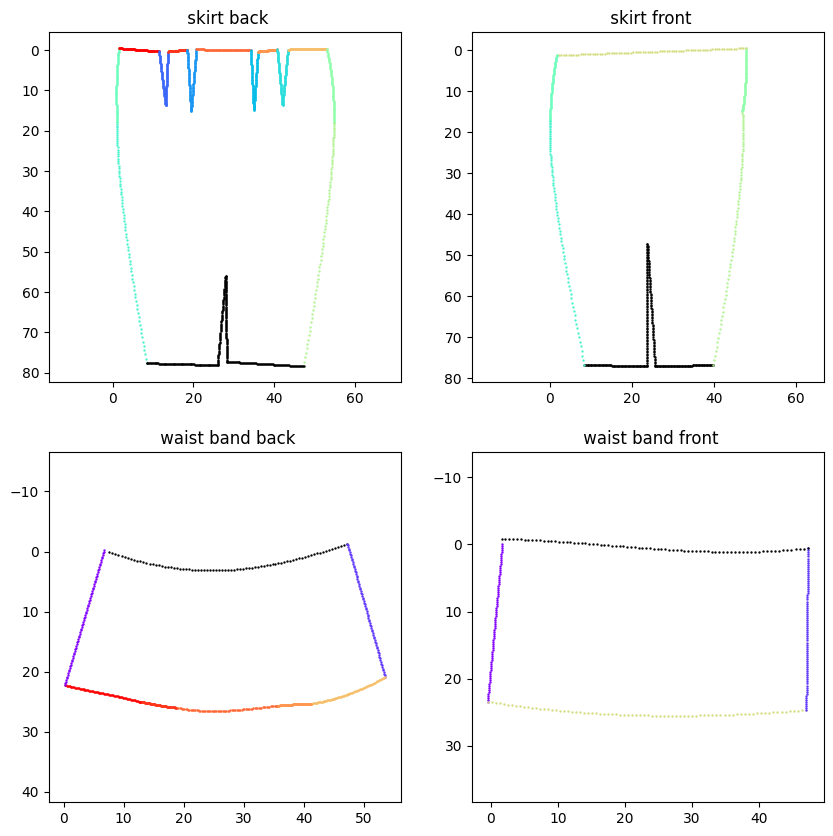

In [29]:
PLOT_N_ROWs = 1
PLOT_N_COLs = 3


few_view_label.make_residual(
    perterb_ratio = 0.2
)

for garment_id in few_view_label.residual_sewing_pattern_dict.keys() :
    orig_sewing_pattern = few_view_label.sewing_pattern_dict[garment_id]
    residual_sewing_pattern = few_view_label.residual_sewing_pattern_dict[garment_id]
    
    orig_sewing_pattern.draw(
        color_list = few_view_label.seam_color_list_dict[garment_id],
        plot_stitch_name=False,
        unify_plot_scale=True,
    )
    
    plt.show()
    
    residual_sewing_pattern.draw(
        color_list = few_view_label.seam_color_list_dict[garment_id],
        plot_stitch_name=False,
        unify_plot_scale=True,
    )
    
    plt.show()
    
    continue
    
    
    for panel_name in orig_sewing_pattern.panel_dict.keys() :
        orig_panel = orig_sewing_pattern.panel_dict[panel_name]
        residual_panel = residual_sewing_pattern.panel_dict[panel_name]
        
        PLOT_IDX = 1
        plt.figure(figsize=(30, 10))
        plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
        orig_panel.draw()
        
        plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
        residual_panel.draw()
        
        plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
        ax = plt.gca()
        orig_panel.draw(
            ax=ax,
            plot_arrow=False,
            edge_color_list=['black'] * len(orig_panel.svg_path),
            N_SAMPLE_PER_EDGE=300,
        )
        residual_panel.draw(
            ax=ax, plot_arrow=False,
            N_SAMPLE_PER_EDGE=300,
        )
        ax.invert_yaxis()
        
        plt.show()
        
        

    
    

In [198]:
new_panel

Panel(svg_path=Path(Line(start=43.63259096413032j, end=(8.208029404703657+43.55738334784082j)),
     Line(start=(8.208029404703657+43.55738334784082j), end=(9.315711643412225+31.20686549948217j)),
     Line(start=(9.315711643412225+31.20686549948217j), end=(10.294474295666468+44.02362658663943j)),
     Line(start=(10.294474295666468+44.02362658663943j), end=(24.749282369211517+43.99155207565888j)),
     Line(start=(24.749282369211517+43.99155207565888j), end=(26.1318524437975+29.620822626481385j)),
     Line(start=(26.1318524437975+29.620822626481385j), end=(13.433393591983519+27.13501976883593j)),
     Line(start=(13.433393591983519+27.13501976883593j), end=(26.499985277212645+25.292976860658122j)),
     Line(start=(26.499985277212645+25.292976860658122j), end=(24.498925307135774+20.937298817471564j)),
     CubicBezier(start=(24.498925307135774+20.937298817471564j), control1=(15.889140488008302+19.20080668878467j), control2=(17.737861121018057+13.959223499697043j), end=(16.24504373132

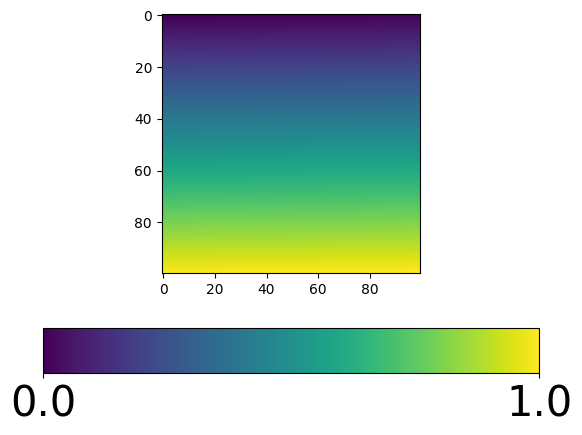

In [33]:
import matplotlib.pyplot as plt
import numpy as np


plt.imshow(np.linspace(0, 1, 10000).reshape(100, 100))
cbar = plt.colorbar(orientation='horizontal', aspect=11)  # Increased aspect ratio makes colorbar taller
cbar.set_ticks([0.0, 1.])
cbar.ax.tick_params(labelsize=30)  # Set font size of colorbar ticks to 14
cbar.ax.set_xticklabels(['{:.1f}'.format(x) for x in cbar.get_ticks()])  # Format as float
plt.show()

In [9]:
## Visualize the panels with colored edges, and save as PNG

# import numpy as np
# import matplotlib.pyplot as plt
# import svgpathtools as svgpath
# from matplotlib.path import Path as MplPath
# from matplotlib.patches import PathPatch

# # sample one svgpathtools segment
# def sample_segment(seg, n=50):
#     ts = np.linspace(0, 1, n)
#     pts = np.array([seg.point(t) for t in ts])
#     return pts.real, pts.imag

# # sample a whole path (for fill polygon)
# def sample_path(path, n_curve=80, n_line=2):
#     all_pts = []
#     for seg in path:
#         n = n_line if isinstance(seg, svgpath.Line) else n_curve
#         x, y = sample_segment(seg, n=n)
#         all_pts.append(np.c_[x, y])
#     all_pts.append([[path[-1].end.real, path[-1].end.imag]])
#     return np.vstack(all_pts)

# def draw_panel_with_colored_edges(
#     panel_path,
#     edge_rgba_list,
#     fill_rgba=(0,0,0,0.2),
#     edge_width=2.0,
#     invert_y=True
# ):
#     fig, ax = plt.subplots(figsize=(6,8))
#     ax.set_aspect("equal")
#     ax.axis("off")

#     # --- draw fill
#     P = sample_path(panel_path)
#     codes = np.full(len(P), MplPath.LINETO, dtype=np.uint8)
#     codes[0] = MplPath.MOVETO
#     codes[-1] = MplPath.CLOSEPOLY
#     mpl_path = MplPath(P, codes)
#     patch = PathPatch(mpl_path, facecolor=fill_rgba, edgecolor=(0,0,0,0))
#     ax.add_patch(patch)

#     # --- draw edges one by one
#     for seg, rgba in zip(panel_path, edge_rgba_list):
#         x, y = sample_segment(seg, n=100)
#         ax.plot(x, y, color=rgba, linewidth=edge_width, solid_capstyle="round")

#     # flip y if needed (SVG coords)
#     if invert_y:
#         ax.invert_yaxis()

#     plt.show()
#     return fig, ax


import numpy as np
import matplotlib.pyplot as plt
import svgpathtools as svgpath
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
import math
import os

# --- helpers you already have/used ---
def sample_segment(seg, n=50):
    ts = np.linspace(0, 1, n)
    pts = np.array([seg.point(t) for t in ts])
    return pts.real, pts.imag

def sample_path(path, n_curve=80, n_line=2):
    all_pts = []
    for seg in path:
        n = n_line if isinstance(seg, svgpath.Line) else n_curve
        x, y = sample_segment(seg, n=n)
        all_pts.append(np.c_[x, y])
    all_pts.append([[path[-1].end.real, path[-1].end.imag]])
    return np.vstack(all_pts)

def _poly_patch(points_xy, fill_rgba):
    P = points_xy
    if np.linalg.norm(P[0] - P[-1]) > 1e-9:
        P = np.vstack([P, P[0]])
    codes = np.full(len(P), MplPath.LINETO, dtype=np.uint8)
    codes[0] = MplPath.MOVETO
    codes[-1] = MplPath.CLOSEPOLY
    return PathPatch(MplPath(P, codes), facecolor=fill_rgba, edgecolor=(0,0,0,0))

# --- NEW: per-panel auto-sized PNG exporter ---
def save_panel_png_scaled(panel_path: svgpath.Path,
                          edge_rgba_list,
                          out_png,
                          fill_rgba=(0,0,0,0.25),
                          stroke_px=3.0,
                          px_per_unit=30.0,     # scale: pixels per coordinate unit
                          margin_px=24,         # transparent padding around the panel
                          dpi=300,
                          invert_y=True,
                          curve_samples=100,    # more samples for smoother curves at large scales
                          line_samples=2):
    """
    Exports one panel as a transparent PNG whose pixel size matches the panel's
    real size (in your SVG units) * px_per_unit, with margin_px padding.
    Edge colors come per segment from edge_rgba_list.
    """
    # 1) sample for fill, get bounds in data units
    P = sample_path(panel_path, n_curve=curve_samples, n_line=line_samples)
    xmin, ymin = P.min(axis=0)
    xmax, ymax = P.max(axis=0)
    width_units  = max(1e-9, xmax - xmin)
    height_units = max(1e-9, ymax - ymin)

    # 2) compute target pixel size (panel size * scale + margins)
    width_px  = int(math.ceil(width_units  * px_per_unit + 2*margin_px))
    height_px = int(math.ceil(height_units * px_per_unit + 2*margin_px))

    # 3) figure size in inches
    fig_w_in = width_px  / dpi
    fig_h_in = height_px / dpi

    fig = plt.figure(figsize=(fig_w_in, fig_h_in), dpi=dpi)
    ax = plt.axes([0,0,1,1])  # full-bleed; no padding
    ax.set_axis_off()
    ax.set_aspect("equal")

    # 4) set axis limits so that 1 unit == px_per_unit pixels
    #    (i.e., bounds expanded by margin expressed in data units)
    margin_units_x = margin_px / px_per_unit
    margin_units_y = margin_px / px_per_unit
    x0 = xmin - margin_units_x
    x1 = xmax + margin_units_x
    y0 = ymin - margin_units_y
    y1 = ymax + margin_units_y
    ax.set_xlim([x0, x1])
    ax.set_ylim([y1, y0] if invert_y else [y0, y1])

    # 5) draw fill (semi-transparent)
    patch = _poly_patch(P, fill_rgba)
    ax.add_patch(patch)

    # 6) draw each edge with its own RGBA, stroke in *pixels*
    lw_pts = stroke_px * 72.0 / dpi  # matplotlib linewidth is in points
    for seg, rgba in zip(panel_path, edge_rgba_list):
        n = curve_samples if not isinstance(seg, svgpath.Line) else line_samples
        x, y = sample_segment(seg, n=n)
        ax.plot(x, y, color=rgba, linewidth=lw_pts, solid_capstyle="round", solid_joinstyle="round")

    # 7) save with full transparency outside the panel
    os.makedirs(os.path.dirname(out_png), exist_ok=True)
    fig.savefig(out_png, dpi=dpi, transparent=True, facecolor=(0,0,0,0))
    plt.close(fig)
    return out_png

In [55]:
R = 0.8980392156862745
G = 0.2980392156862745
B = 0.9254901960784314

R = 241 / 255
G = 164 / 255
B = 244 / 255

R = 162
G = 114
B = 164

# R, G, B = 59, 88, 149
# R, G, B = R / 255, G / 255, B / 255
# PANEL_FILL_COLOR   = (R, G, B, 0.65)


R_F = 131
G_F = 154
B_F = 203

R_B = 17
G_B = 28
B_B = 59


R_B = 9
G_B = 14
B_B = 25

R_F, G_F, B_F = R_F / 255, G_F / 255, B_F / 255
R_B, G_B, B_B = R_B / 255, G_B / 255, B_B / 255

PANEL_FILL_COLOR_FRONT = (R_F, G_F, B_F, 0.85)
PANEL_FILL_COLOR_BACK  = (R_B, G_B, B_B, 0.55)
# PANEL_FILL_COLOR_BACK  = (R_F, G_F, B_F, 1.0)

NO_STCH_EDGE_COLOR = (R_F, G_F, B_F, 0.3)
# NO_STCH_EDGE_COLOR = (0.01, 0.01, 0.01, 0.0)

for garment_id, sewing_pattern in few_view_label.sewing_pattern_dict.items() :
    stitch_dict = sewing_pattern.stitch_dict
    for panel_name, panel in sewing_pattern.panel_dict.items() :
        
        # no_arc_panel = deepcopy(panel)
        # no_arc_panel.approximate_arc_with_cubic_bezier()
        
        color_list = []
        
        # for edge_idx, edge in enumerate(no_arc_panel.svg_path) :
        for edge_idx, edge in enumerate(panel.svg_path) :
            stitch_idx = None
            # for stitch_idx, stc in enumerate(stitch_dict) :
            
            for stc_idx, stc in stitch_dict.items() :
                if (
                    stc.panel_0 == panel_name and stc.edge_0 == edge_idx
                ) or (
                    stc.panel_1 == panel_name and stc.edge_1 == edge_idx
                ) :
                    stitch_idx = stc_idx
                    break

            if stitch_idx is None :
                color = np.array(NO_STCH_EDGE_COLOR)
                edge.color = color
            else :
                color = few_view_label.seam_color_list_dict[garment_id][stitch_idx]
                edge.color = color
                
            color_list.append(color)
            

        edge_rgba_list = list(map(
            lambda x : tuple(x.tolist()),
            color_list
        ))

        
        # fig, ax = draw_panel_with_colored_edges(
        #     panel.svg_path,
        #     edge_rgba_list,
        #     fill_rgba=(0.01,0.01,0.01,0.1),
        #     edge_width=5.0
        # )
        # fig.tight_layout()
        # fig.savefig(
        #     os.path.join(
        #         "VIS",
        #         panel_name + ".png"
        #     ),
        #     dpi=300,
        #     transparent=True
        # )
                
        out_png = os.path.join(
            "VIS",
            os.path.basename(few_view_label.garment_dir),
            garment_id,
            f"{panel_name}.png"
        )
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        save_panel_png_scaled(
            panel.svg_path,
            edge_rgba_list,
            out_png     = out_png,
            fill_rgba   = PANEL_FILL_COLOR_FRONT if "front" in panel_name else PANEL_FILL_COLOR_BACK,  # panel interior opacity/color
            stroke_px   = 10.0,                    # edge thickness in pixels
            px_per_unit = 10.0,                 # <<< scale: tune this so units → pixels feels right
            margin_px   = 24,
            dpi         = 300,
            invert_y    = True,
            curve_samples = 120,                # bump for smoother curves on large panels
            line_samples= 2
        )

In [283]:
few_view_label.garment_dir

'SAMPLE_DATA/0814/rand_3YKPGXYGVG__01__rand_7SRESBECDF__01'

### Deprecated

In [ ]:
## Test cell for perturbing the panels

import svgpathtools as svgpath

PERTERB_RATIO = 0.2


PLOT_N_ROWs = 1
PLOT_N_COLs = 3

for panel_name, panel in sewing_pattern.panel_dict.items() :   
    
    panel_no_arc = deepcopy(panel)
    panel_no_arc.approximate_arc_with_cubic_bezier()
    
    
    PLOT_IDX = 1
    plt.figure(figsize=(30, 10))
    plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
    panel_no_arc.draw()
    
    stt_pos = panel_no_arc.svg_path[0].start
    prev_end_pos = panel_no_arc.svg_path[0].start

    print(stt_pos)
    
    new_svg_path = []
    for edge in panel_no_arc.svg_path :
        
        scale = edge.length() * PERTERB_RATIO
        
        if edge.end == stt_pos :
            end_pos = edge.end
            
        else :
            end_x_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            end_y_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            end_pos = edge.end + end_x_perterb + end_y_perterb * 1j

        
        if isinstance(edge, svgpath.Line) :
            new_svg_path.append(svgpath.Line(start = prev_end_pos, end = end_pos))
        elif isinstance(edge, svgpath.CubicBezier) :
            control1_x_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            control1_y_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            control2_x_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            control2_y_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            
            control1_pos = edge.control1 + control1_x_perterb + control1_y_perterb * 1j
            control2_pos = edge.control2 + control2_x_perterb + control2_y_perterb * 1j
            
            new_svg_path.append(svgpath.CubicBezier(start=prev_end_pos, end=end_pos, control1=control1_pos, control2=control2_pos))
        elif isinstance(edge, svgpath.QuadraticBezier) :
            control_x_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            control_y_perterb = random.uniform(-PERTERB_RATIO, PERTERB_RATIO) * scale
            
            control_pos = edge.control + control_x_perterb + control_y_perterb * 1j
            
            new_svg_path.append(svgpath.QuadraticBezier(start=prev_end_pos, end=end_pos, control=control_pos))
        else :
            raise ValueError(f"Unknown edge type: {type(edge)}")
        
        prev_end_pos = deepcopy(end_pos)
        
    # new_svg_path[-1].end = stt_pos
    
    new_panel = SVGPanel(svgpath.Path(*new_svg_path))
    
    plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
    new_panel.draw(plot_arrow=False)
    
    
    plt.subplot(PLOT_N_ROWs, PLOT_N_COLs, PLOT_IDX); PLOT_IDX += 1
    
    ax = plt.gca()
    panel_no_arc.draw(
        ax=ax,
        plot_arrow=False,
        edge_color_list=['black'] * len(panel_no_arc.svg_path),
        N_SAMPLE_PER_EDGE=300
    )
    new_panel.draw(
        ax=ax,
        plot_arrow=False,
        N_SAMPLE_PER_EDGE=300
    )
    ax.invert_yaxis()
    
    print(len(panel.edge_len_list), len(panel_no_arc.edge_len_list), len(new_panel.edge_len_list))
    
    plt.show()
        

In [ ]:
# 수정 시 대칭으로 하도록 함.

few_view_label.seam_color_list_dict

few_view_label.sewing_pattern_dict

few_view_label.sewing_pattern_dict['rand_40B81PVUQ2'].stitch_dict


for garment_id, sewing_pattern in few_view_label.sewing_pattern_dict.items() :
    
    print(garment_id)
    print("=")
    
    stitch_dict = sewing_pattern.stitch_dict
    
    for panel_name, panel in sewing_pattern.panel_dict.items() :
        
        print(panel_name)
        
        no_arc_panel = deepcopy(panel)
        no_arc_panel.approximate_arc_with_cubic_bezier()
        
        color_list = []
        # for edge_idx, edge in enumerate(no_arc_panel.svg_path) :
        for edge_idx, edge in enumerate(panel.svg_path) :
            stitch_idx = None
            # for stitch_idx, stc in enumerate(stitch_dict) :
            for stc_idx, stc in stitch_dict.items() :
                if (
                    stc.panel_0 == panel_name and stc.edge_0 == edge_idx
                ) or (
                    stc.panel_1 == panel_name and stc.edge_1 == edge_idx
                ) :
                    stitch_idx = stc_idx
                    break

            if stitch_idx is None :
                color = np.array([0., 0., 0., 1.])
                edge.color = color
            else :
                color = few_view_label.seam_color_list_dict[garment_id][stitch_idx]
                edge.color = color
                
            print(color, edge)
            color_list.append(color)
            
        print()
    
        plt.subplot(1, 2, 2); no_arc_panel.draw(plot_arrow=False, edge_color_list=color_list)
        plt.subplot(1, 2, 1); panel.draw(plot_arrow=False, edge_color_list=color_list)
        plt.show()
        
        
    print()
    
    plt.show()
    